In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

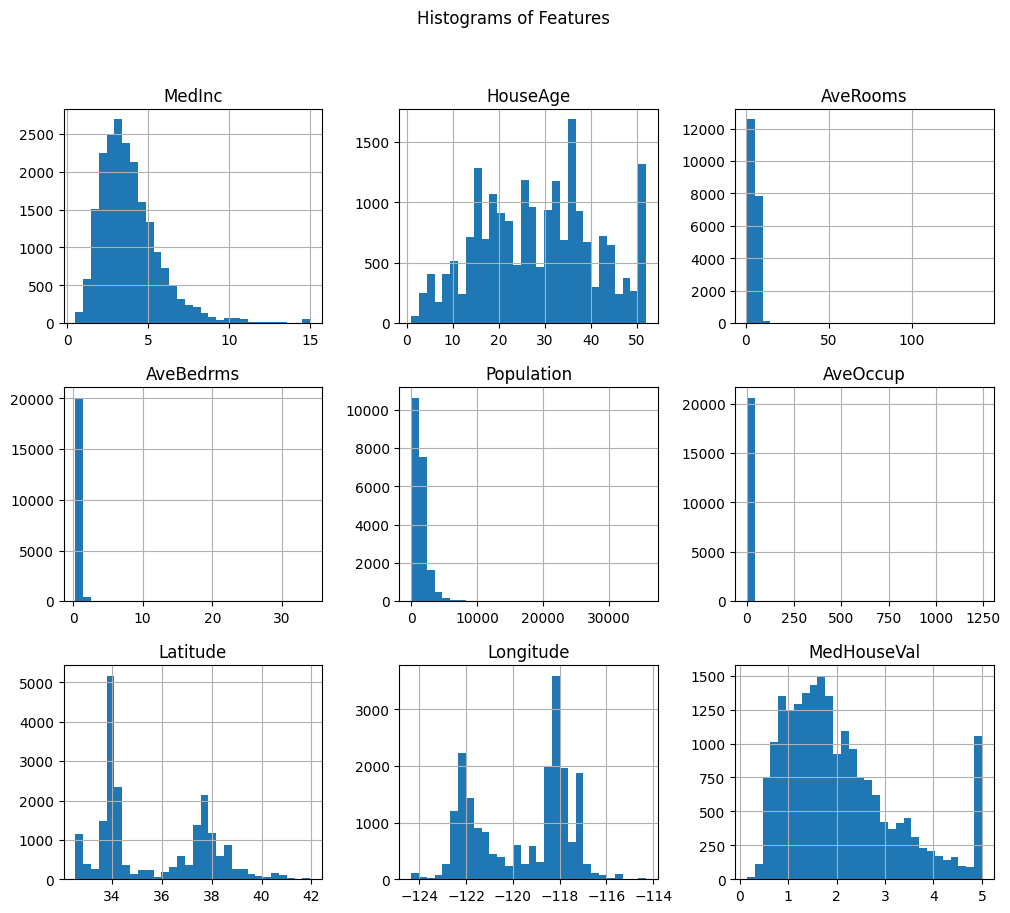

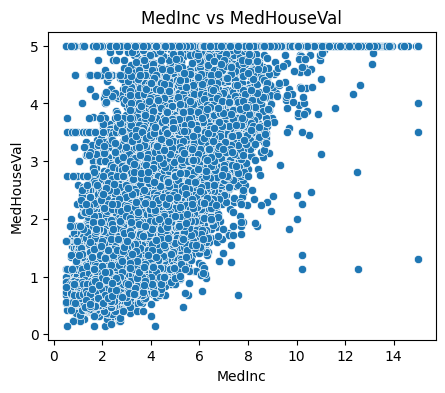

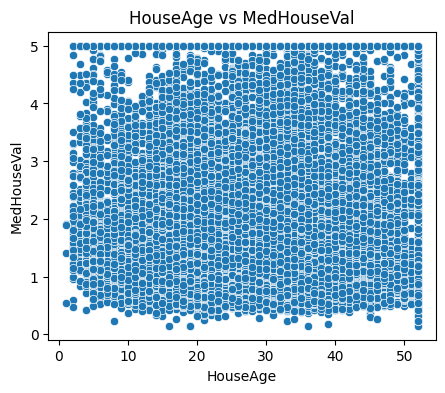

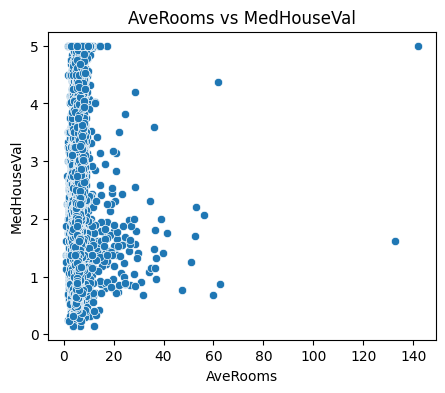

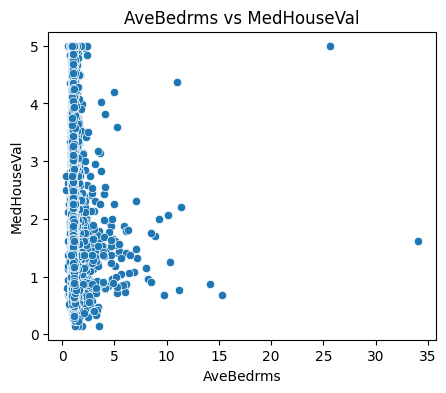

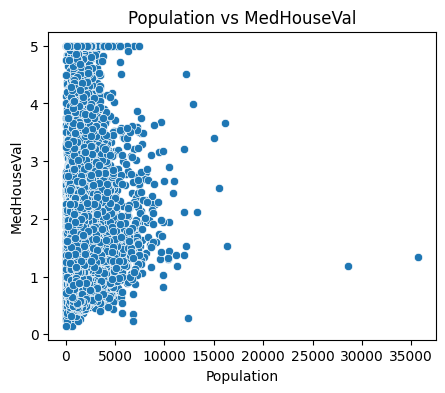

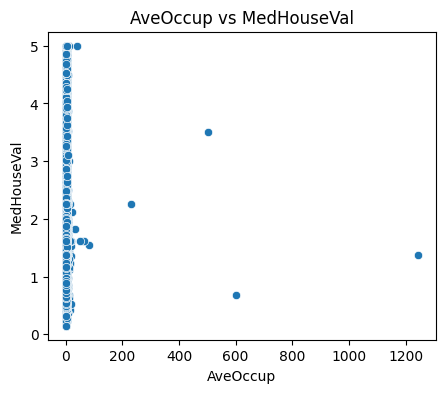

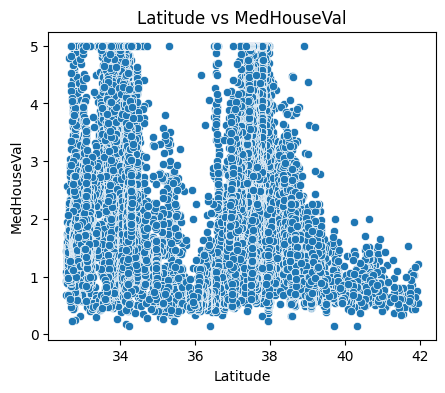

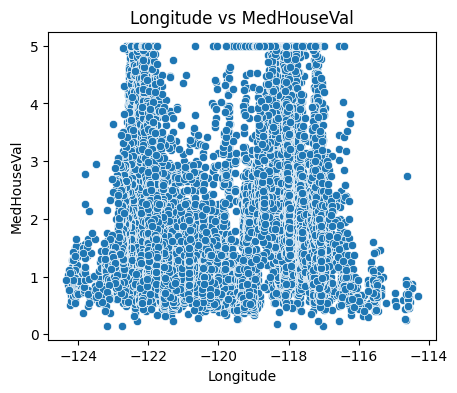

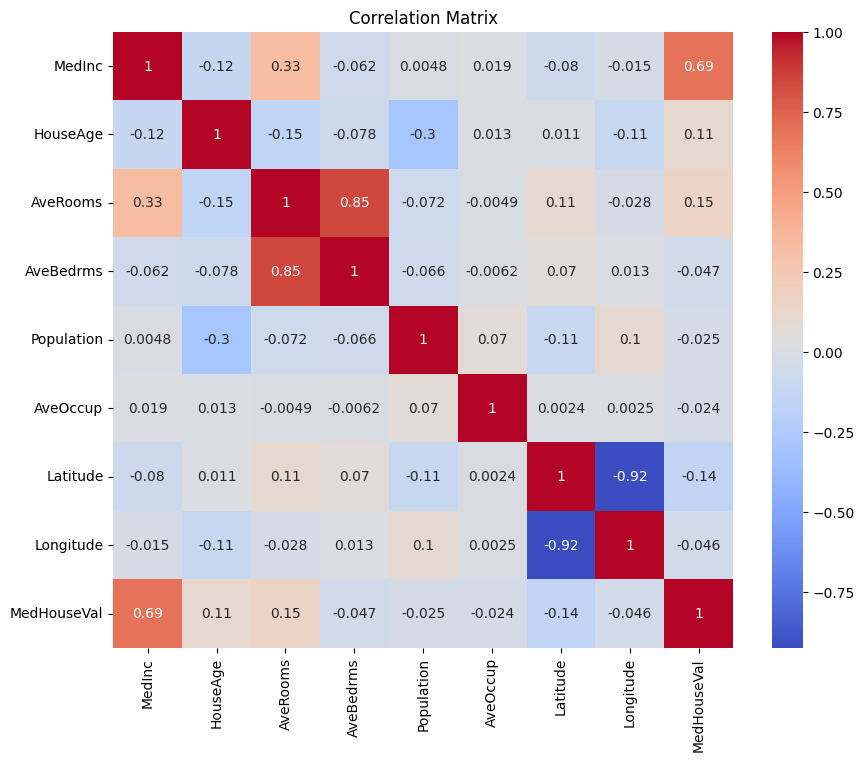

In [2]:
#1 Exploratory Data Analysis 
print(df.describe())

df.hist(figsize=(12,10), bins=30)
plt.suptitle("Histograms of Features")
plt.show()

for col in housing.feature_names:
    plt.figure(figsize=(5,4))
    sns.scatterplot(x=df[col], y=df['MedHouseVal'])
    plt.title(f"{col} vs MedHouseVal")
    plt.show()

plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [3]:
#2
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
coeff_full = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})
intercept_full = model.intercept_
print("Intercept:", intercept_full)
print(coeff_full,'\n')

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X.shape[1])]
print(vif)

Intercept: -37.02327770606416
      Feature  Coefficient
0      MedInc     0.448675
1    HouseAge     0.009724
2    AveRooms    -0.123323
3   AveBedrms     0.783145
4  Population    -0.000002
5    AveOccup    -0.003526
6    Latitude    -0.419792
7   Longitude    -0.433708 

      feature         VIF
0      MedInc   11.831609
1    HouseAge    7.155405
2    AveRooms   46.792373
3   AveBedrms   48.332634
4  Population    2.915730
5    AveOccup    1.080609
6    Latitude  560.583263
7   Longitude  641.224254


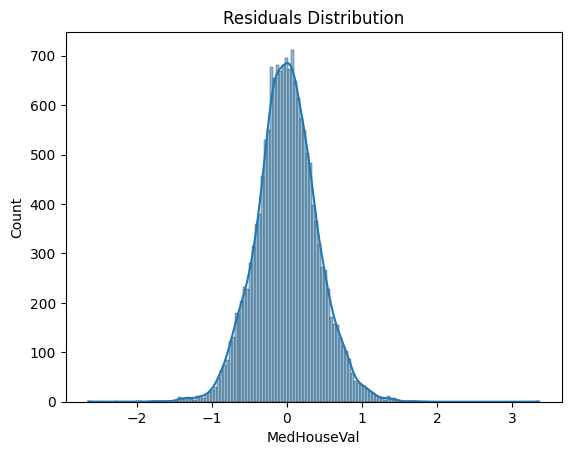

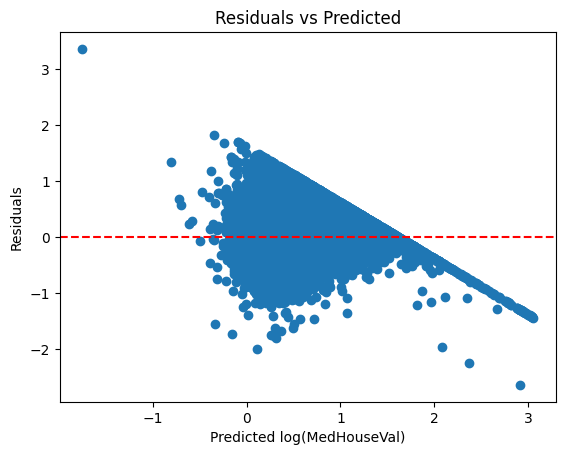

In [4]:
#3 Model Refinement
X_refined = df[['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Latitude']]
y = df['MedHouseVal']
y_log = np.log(y)

X_train, X_test, y_train, y_test = train_test_split(X_refined, y_log, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)   
residuals = y_train - y_train_pred     
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()
plt.scatter(y_train_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted log(MedHouseVal)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

In [5]:
#4
X_train, X_test, y_train, y_test = train_test_split(X_refined, y_log, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
intercept = model.intercept_
coefficients = pd.DataFrame({
    'Feature': X_refined.columns,
    'Coefficient': model.coef_
})
print("Intercept:", intercept)
print(coefficients)

vif = pd.DataFrame()
vif["feature"] = X_refined.columns
vif["VIF"] = [variance_inflation_factor(X_refined.values, i) for i in range(X_refined.shape[1])]
print("VIF \n", vif)

Intercept: 0.8188020631980619
      Feature  Coefficient
0      MedInc     0.206232
1    HouseAge     0.007369
2    AveRooms    -0.013197
3  Population     0.000023
4    AveOccup    -0.002060
5    Latitude    -0.033960
VIF 
       feature        VIF
0      MedInc   5.640759
1    HouseAge   6.766700
2    AveRooms   6.821976
3  Population   2.773339
4    AveOccup   1.094801
5    Latitude  19.302219


In [6]:
y_log = np.log(df['MedHouseVal'])
X_train, X_test, y_train, y_test = train_test_split(X_refined, y_log, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_log = model.predict(X_test)
r2_log = r2_score(y_test, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))

print("Test R² (log target):", r2_log)
print("Test RMSE (log target):", rmse_log)


y = df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X_refined, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Test R² (original target):", r2)
print("Test RMSE (original target):", rmse)

Test R² (log target): 0.470972191915738
Test RMSE (log target): 0.41437226028835905
Test R² (original target): 0.5059804263462322
Test RMSE (original target): 0.8045916260704177
